In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
try:
    major_version, minor_version = torch.cuda.get_device_capability()
    !pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

    if major_version >= 8:
        !pip install --no-deps xformers trl peft accelerate bitsandbytes
    else:
        !pip install --no-deps xformers trl peft accelerate bitsandbytes

    print("Cài đặt xong")
except Exception as e:
    print(f"Lỗi: Hãy đảm bảo bạn đã bật GPU Chi tiết: {e}")

Mounted at /content/drive
  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-x3lykcxv/unsloth_9e98fec0b8be4a3f9b2fb8d017b484ee
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-x3lykcxv/unsloth_9e98fec0b8be4a3f9b2fb8d017b484ee
  Resolved https://github.com/unslothai/unsloth.git to commit 040b80a60e6bf0278c0b81ee986cf9b87b9d4f6d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.

In [ ]:
from unsloth import FastLanguageModel
import torch
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)
print("✅ Tải mô hình thành công ")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ Tải mô hình thành công 


In [ ]:
import pandas as pd
from datasets import Dataset
from unsloth import FastLanguageModel
import torch

# 1. CÀI ĐẶT THÔNG SỐ CƠ BẢN
max_seq_length = 1024
dtype = None
load_in_4bit = True

print("🔄 Đang tải bộ não Qwen2.5 mới tinh (Tẩy não)...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

# 2. XỬ LÝ DỮ LIỆU & CÂN BẰNG (UNDERSAMPLING)
print("⚖️ Đang tải và cân bằng dữ liệu 50-50...")
df_train = pd.read_json("/content/drive/MyDrive/train_data.jsonl", lines=True)

def get_label_from_messages(msg_list):
    for msg in msg_list:
        if msg['role'] == 'assistant':
            return int(msg['content'])
    return 0

df_train['temp_label'] = df_train['messages'].apply(get_label_from_messages)

df_tin_that = df_train[df_train['temp_label'] == 0]
df_tin_gia = df_train[df_train['temp_label'] == 1]

# Cắt bằng nhau
so_luong_tin_gia = len(df_tin_gia)
df_tin_that_da_cat = df_tin_that.sample(n=so_luong_tin_gia, random_state=42)
df_train_balanced = pd.concat([df_tin_that_da_cat, df_tin_gia]).sample(frac=1, random_state=42).reset_index(drop=True)

# 3. ÉP KHUÔN CHUẨN
system_prompt = """Bạn là một chuyên gia phát hiện tin giả tiếng Việt. Nhiệm vụ của bạn là đọc bài báo và phân loại nó.
LUẬT CHƠI BẮT BUỘC:
- Nếu là Tin thật, in ra đúng một số: 0
- Nếu là Tin giả, in ra đúng một số: 1
Tuyệt đối KHÔNG giải thích."""

def format_strict_prompt(row):
    user_text = ""
    assistant_label = ""
    for tin_nhan in row['messages']:
        if tin_nhan['role'] == 'user':
            user_text = tin_nhan['content']
        elif tin_nhan['role'] == 'assistant':
            assistant_label = tin_nhan['content']

    prompt = f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
    prompt += f"<|im_start|>user\n{user_text}<|im_end|>\n"
    prompt += f"<|im_start|>assistant\n{assistant_label}<|im_end|>"
    return prompt

df_train_balanced['text'] = df_train_balanced.apply(format_strict_prompt, axis=1)
train_data = Dataset.from_pandas(df_train_balanced)

df_test = pd.read_json("/content/drive/MyDrive/test_data.jsonl", lines=True)
df_test['text'] = df_test.apply(format_strict_prompt, axis=1)
test_data = Dataset.from_pandas(df_test)

print(f"✅ Hoàn tất! Tập Train cân bằng: {len(train_data)} mẫu | Tập Test: {len(test_data)} mẫu")

🔄 Đang tải bộ não Qwen2.5 mới tinh (Tẩy não)...
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
⚖️ Đang tải và cân bằng dữ liệu 50-50...
✅ Hoàn tất! Tập Train cân bằng: 3286 mẫu | Tập Test: 659 mẫu


In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback
from trl import SFTTrainer
from sklearn.metrics import accuracy_score, f1_score
from unsloth import is_bfloat16_supported

print("🚀 Bắt đầu cấu hình Huấn luyện...")

def preprocess_logits_for_metrics(logits, labels):
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.argmax(dim=-1)

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    mask = labels != -100
    labels_filtered = labels[mask]
    preds_filtered = preds[mask]

    try:
        decoded_preds = tokenizer.batch_decode(preds_filtered, skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels_filtered, skip_special_tokens=True)
        y_pred = [1 if '1' in str(p) else 0 for p in decoded_preds]
        y_true = [1 if '1' in str(l) else 0 for l in decoded_labels]
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)
    except Exception as e:
        acc, f1 = 0, 0
    return {"Accuracy": acc, "F1": f1}

training_args = TrainingArguments(
    output_dir = "qwen_results_best",
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps = 5,
    num_train_epochs = 5,  # Cho chạy 5 vòng vì dữ liệu đã ít đi
    learning_rate = 2e-4,
    fp16 = not is_bfloat16_supported(),
    bf16 = is_bfloat16_supported(),

    eval_strategy = "epoch",
    logging_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "eval_F1",

    optim = "adamw_8bit",
    weight_decay = 0.01,
    lr_scheduler_type = "linear",
    seed = 3407,
)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_data,
    eval_dataset = test_data,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,
    args = training_args,
    compute_metrics = compute_metrics,
    preprocess_logits_for_metrics = preprocess_logits_for_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # Cho phép hụt 2 lần
)

print("⏳ Đang tiến hành huấn luyện. Vui lòng chờ xem bảng kết quả...")
trainer_stats = trainer.train()
print("\n🎉 ĐÃ HUẤN LUYỆN XONG VÀ LƯU MÔ HÌNH TỐT NHẤT!")

🚀 Bắt đầu cấu hình Huấn luyện...


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/3286 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/659 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


⏳ Đang tiến hành huấn luyện. Vui lòng chờ xem bảng kết quả...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,286 | Num Epochs = 5 | Total steps = 2,055
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.263329,0.987380,1.000000,1.000000
2,1.073856,0.981228,1.000000,1.000000
3,0.937858,0.991789,1.000000,1.000000


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


🎉 ĐÃ HUẤN LUYỆN XONG VÀ LƯU MÔ HÌNH TỐT NHẤT!


📝 Qwen đang làm bài thi. Xin vui lòng đợi...


  0%|          | 0/659 [00:00<?, ?it/s]Both `max_new_tokens` (=5) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, Fut


🏆 KẾT QUẢ CUỐI CÙNG CỦA QWEN2.5 TRÊN TẬP TEST 🏆
✅ Accuracy  : 69.95%
✅ Precision : 50.56%
✅ Recall    : 67.66%
✅ F1-Score  : 57.87%


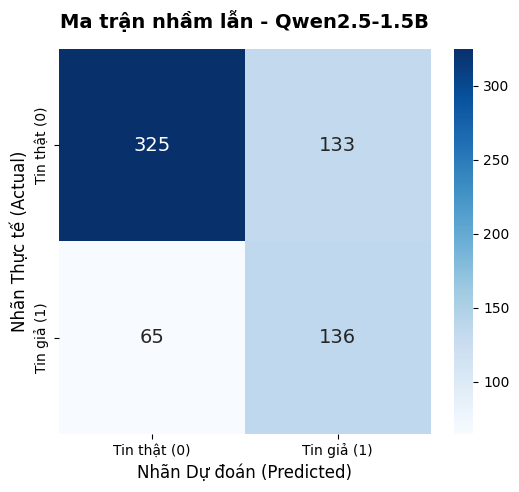


📸 Ảnh ma trận đã lưu: qwen_confusion_matrix_final.png


In [ ]:
import torch
import re
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

FastLanguageModel.for_inference(model)

y_true = []
y_pred = []

print("📝 Qwen đang làm bài thi. Xin vui lòng đợi...")
for i in tqdm(range(len(df_test))):
    user_text = ""
    actual_label = 0
    for tin_nhan in df_test['messages'].iloc[i]:
        if tin_nhan['role'] == 'user':
            user_text = tin_nhan['content']
        elif tin_nhan['role'] == 'assistant':
            actual_label = int(tin_nhan['content'])

    prompt = f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
    prompt += f"<|im_start|>user\n{user_text}<|im_end|>\n"
    prompt += f"<|im_start|>assistant\n"

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=5, use_cache=True, pad_token_id=tokenizer.eos_token_id)
    predicted_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    pred_str = predicted_text.split("assistant\n")[-1].strip()
    match = re.search(r'[01]', pred_str)
    pred_label = int(match.group()) if match else 0

    y_true.append(actual_label)
    y_pred.append(pred_label)

# IN THÔNG SỐ VÀ VẼ HÌNH
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n" + "="*50)
print("🏆 KẾT QUẢ CUỐI CÙNG CỦA QWEN2.5 TRÊN TẬP TEST 🏆")
print("="*50)
print(f"✅ Accuracy  : {acc*100:.2f}%")
print(f"✅ Precision : {prec*100:.2f}%")
print(f"✅ Recall    : {rec*100:.2f}%")
print(f"✅ F1-Score  : {f1*100:.2f}%")
print("="*50)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Tin thật (0)", "Tin giả (1)"],
            yticklabels=["Tin thật (0)", "Tin giả (1)"],
            annot_kws={"size": 14})

plt.title('Ma trận nhầm lẫn - Qwen2.5-1.5B', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nhãn Dự đoán (Predicted)', fontsize=12)
plt.ylabel('Nhãn Thực tế (Actual)', fontsize=12)

plt.savefig('qwen_confusion_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n📸 Ảnh ma trận đã lưu: qwen_confusion_matrix_final.png")